In [ ]:
import numpy as np

from pyfield.scans import DopplerScan
from pyfield.utilities import (add_3D_vol, add_2D_image, add_regions_mesh, add_transducer_mesh, add_pressure_vol)

from pyfield.brain_atlas import BG_Atlas

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Functions 

# 2. Read and visualize the scans

In [73]:
MAIN_FOLDER_PATH = r"..\src\pyfield\datatype\Silvia"

bps_PATH = MAIN_FOLDER_PATH + r"\3Dscan_angio3D.source.bps"
file_scan_3D_PATH = MAIN_FOLDER_PATH + r"\3Dscan_angio3D.source.scan"
file_scan_2D_PATH = MAIN_FOLDER_PATH + r"\2Dscan.source.scan"
markers_PATH = MAIN_FOLDER_PATH + r"\markers_coronal.mrk"

# Let's take the 008 scan. It shouwld be placed at one sagittal plane on the left side of the brain

In [74]:
Doppler3D = DopplerScan(scan_PATH=file_scan_3D_PATH, bps_PATH = bps_PATH)
Doppler3D.summary()

Scan data loaded from ..\src\pyfield\datatype\Silvia\3Dscan_angio3D.source.scan. Shape: (61, 1, 102, 1, 128)
Probe to Lab transformation matrix loaded. Shape: (61, 4, 4)
Probe to Lab transformation matrix is 3D. Taking the first slice.
BPS path provided. Using it to compute the sform matrix.
DopplerScan 3D object created successfully.
PyVista mesh reset on Lab coordinate system.
----------DopplerScan Summary:----------
scan_PATH: ..\src\pyfield\datatype\Silvia\3Dscan_angio3D.source.scan
bps_PATH: ..\src\pyfield\datatype\Silvia\3Dscan_angio3D.source.bps
probe_type: Linear
mean_frames: True
verbose: False
data: array with shape (128, 61, 102)
scan_type: 3D
probeToLab: [[ 0.        1.        0.       -0.007499]
 [-1.        0.        0.        0.0056  ]
 [ 0.        0.        1.       -0.0513  ]
 [ 0.        0.        0.        1.      ]]
voxelsToProbe: [[ 1.10000e-04  0.00000e+00  0.00000e+00 -7.09500e-03]
 [ 0.00000e+00  1.00000e-04  0.00000e+00 -1.00000e-04]
 [ 0.00000e+00  0.00000e+00

Plotting y-planes of scan with shape (128, 61, 102)


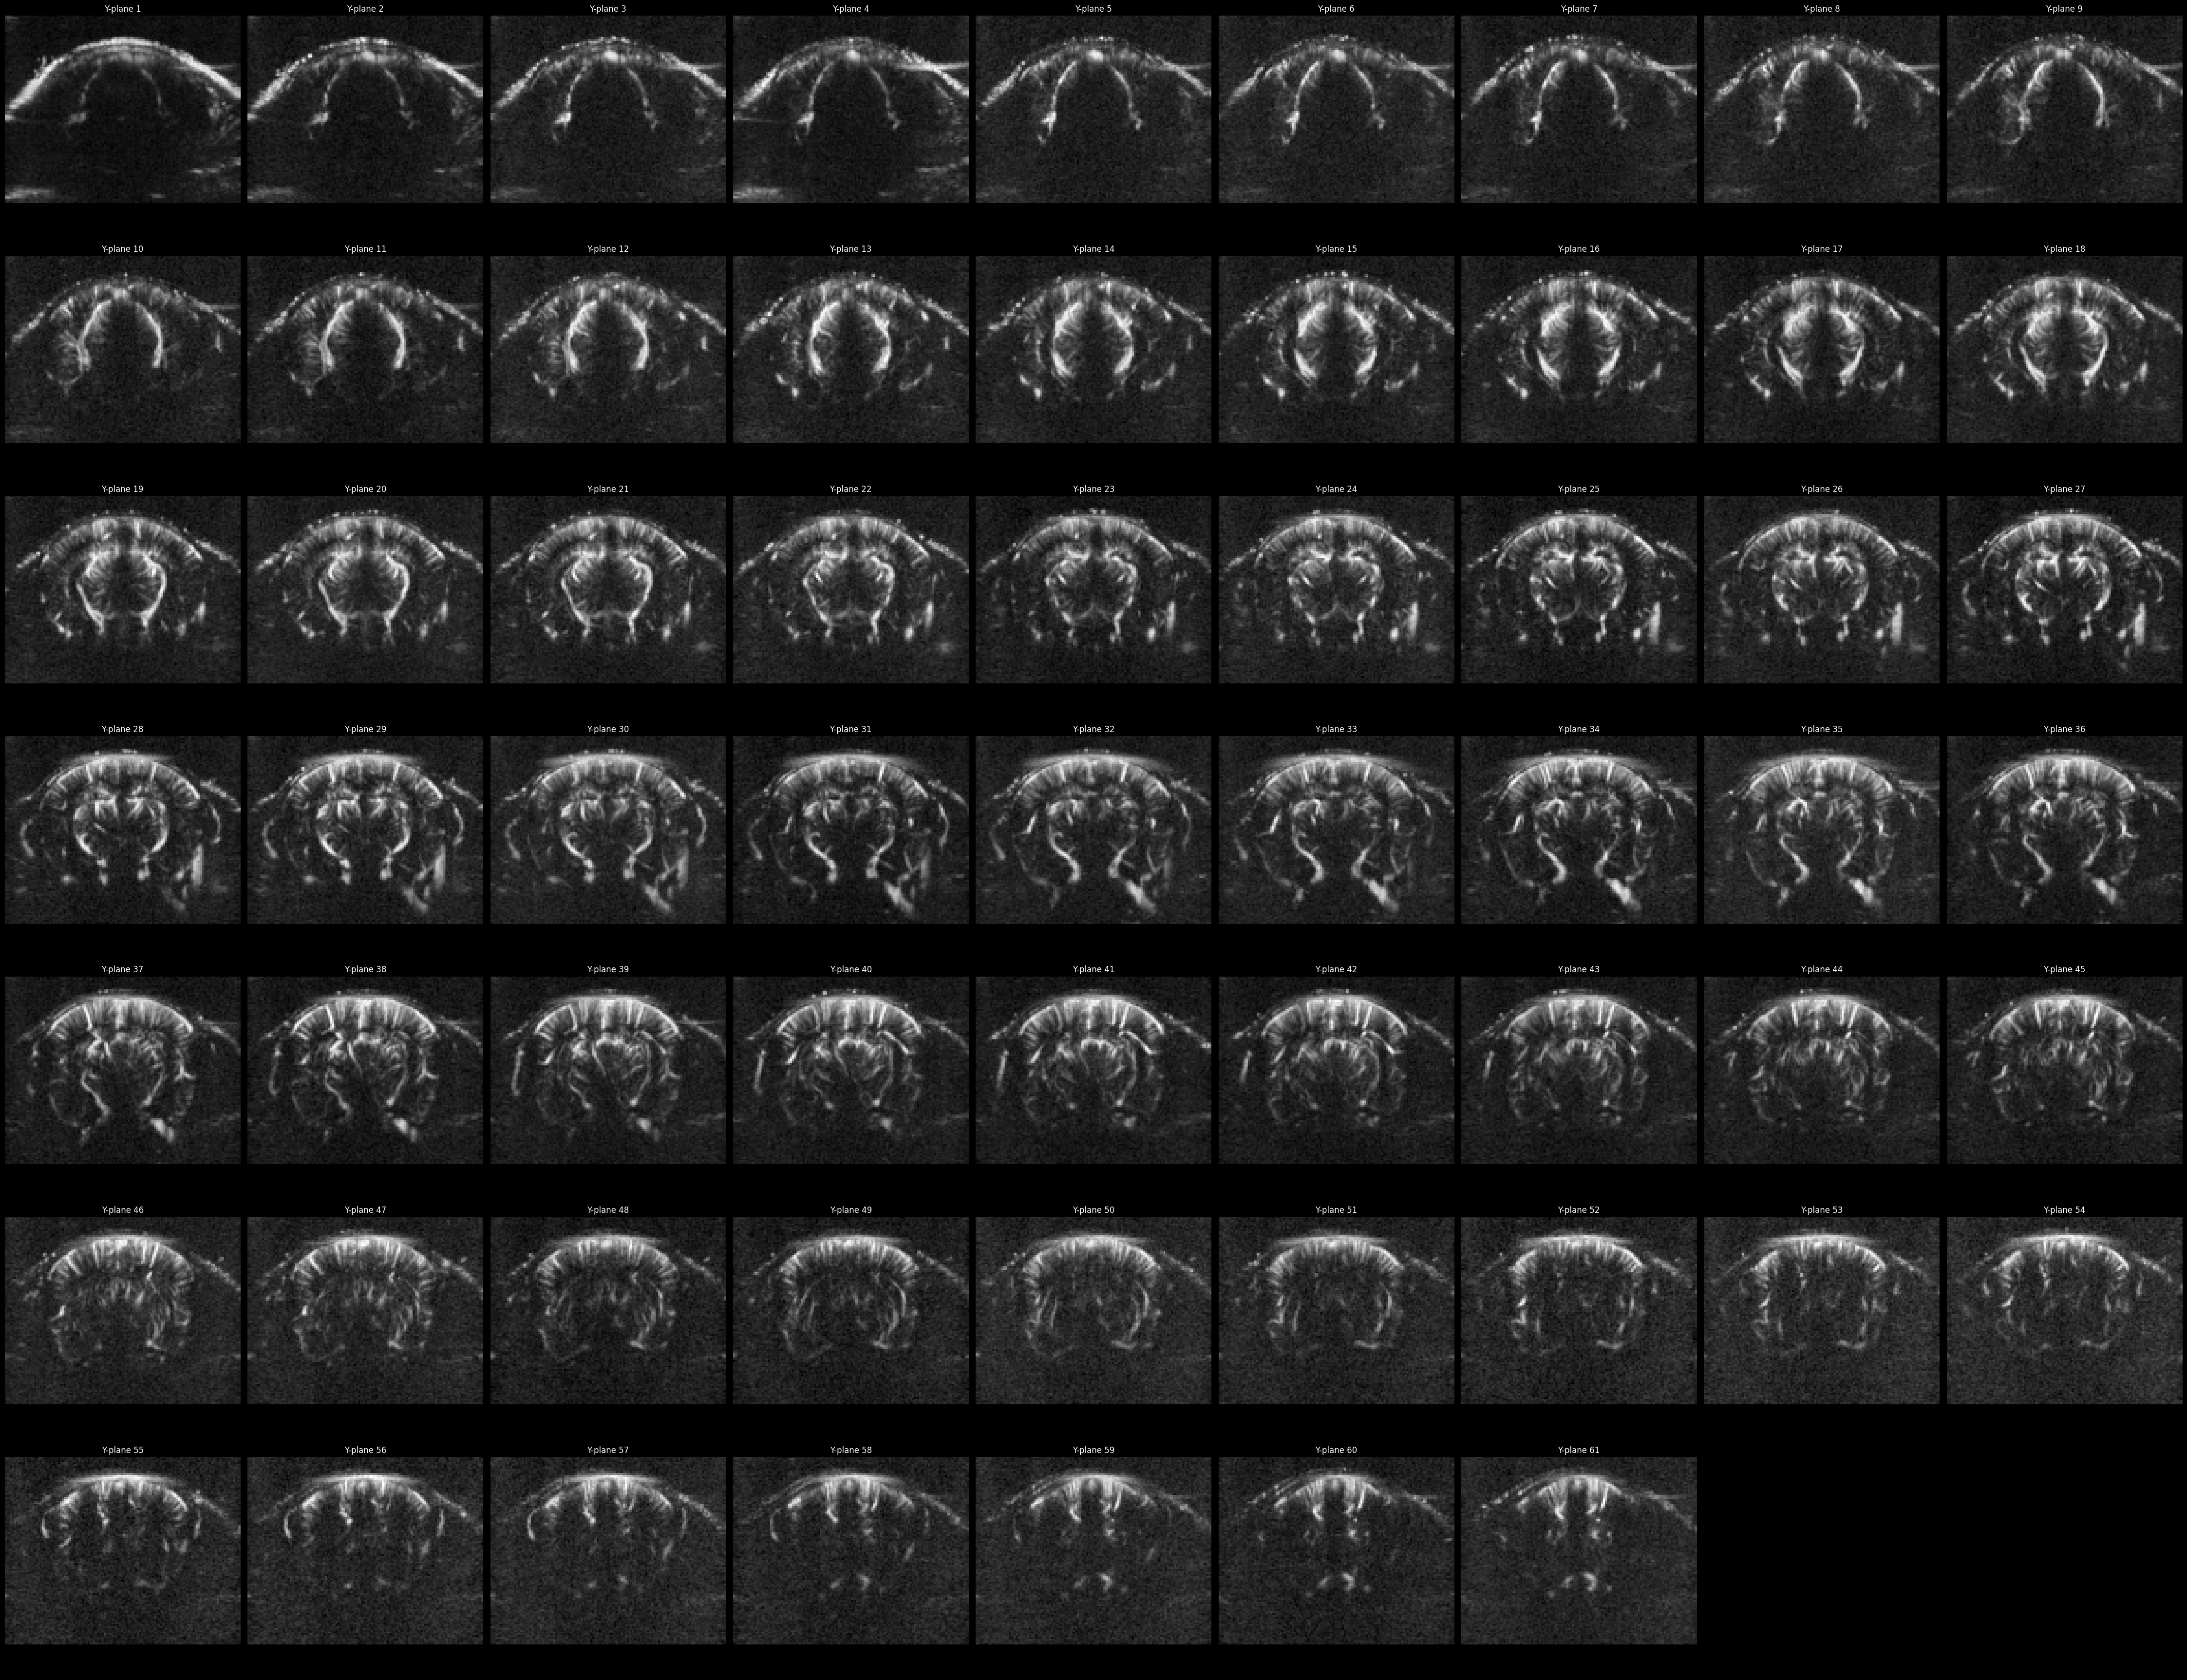

In [75]:
Doppler3D.show()

In [76]:
Doppler2D = DopplerScan(scan_PATH=file_scan_2D_PATH)
Doppler2D.summary()

Scan data loaded from ..\src\pyfield\datatype\Silvia\2Dscan.source.scan. Shape: (775, 102, 1, 128)
Probe to Lab transformation matrix loaded. Shape: (4, 4)
No BPS path provided. No way to get to the Brain space. Returning s_form as identity.
DopplerScan 2D object created successfully.
Data contains zero values. No convertion to dB is done.
PyVista mesh reset on Lab coordinate system.
----------DopplerScan Summary:----------
scan_PATH: ..\src\pyfield\datatype\Silvia\2Dscan.source.scan
bps_PATH: None
probe_type: Linear
mean_frames: True
verbose: False
scan_type: 2D
data: array with shape (128, 1, 102)
probeToLab: [[-9.99999e-01  1.00000e-05  0.00000e+00 -6.64800e-03]
 [-1.00000e-05 -9.99999e-01  0.00000e+00  3.16300e-03]
 [ 0.00000e+00  0.00000e+00  1.00000e+00 -5.13000e-02]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]
voxelsToProbe: [[ 1.10000e-04  0.00000e+00  0.00000e+00 -7.09500e-03]
 [ 0.00000e+00  4.00000e-04  0.00000e+00 -4.00000e-04]
 [ 0.00000e+00  0.00000e+00 -9.8560

Plotting y-planes of scan with shape (128, 1, 102)
Data contains zero values. No convertion to dB is done.


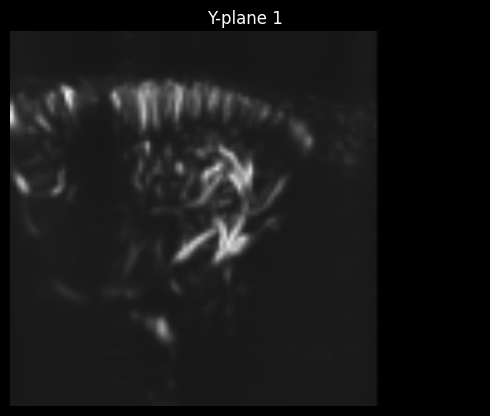

In [77]:
Doppler2D.show(interpolation = 'bilinear')

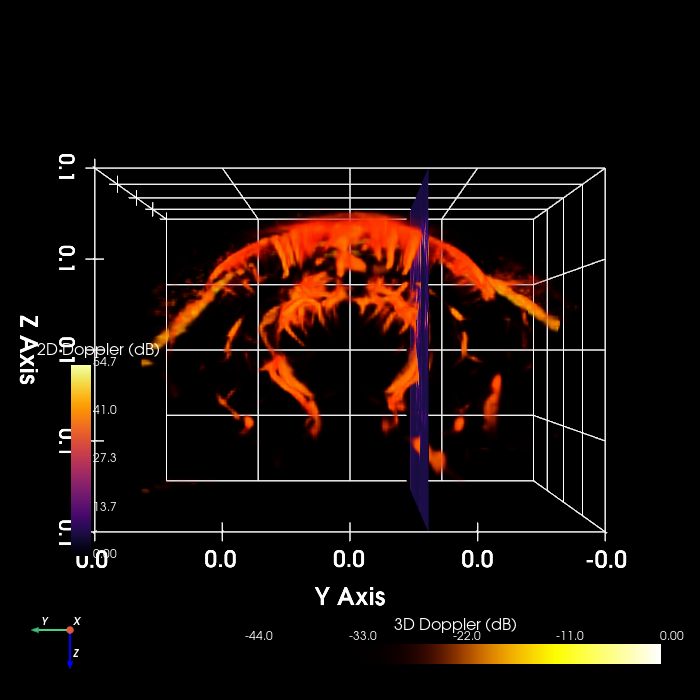

In [78]:
plotter_lab = add_3D_vol(Doppler3D.pv_mesh, notebook = True, cmap="hot", opacity="sigmoid_10",
                         scalar_bar_args={
                               'title': '3D Doppler (dB)',
                               "title_font_size": 16,
                               "label_font_size": 12,
                               'color' : 'white',
                           })

plotter_lab = add_2D_image(Doppler2D.pv_mesh, plotter=plotter_lab, cmap='inferno', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1,
                           scalar_bar_args={
                               'title': '2D Doppler (dB)',
                               "title_font_size": 16,
                               "label_font_size": 12,
                               'vertical': True,
                               'position_x': 0.1,
                               'position_y': 0.2,
                               "height": 0.3,
                               'color' : 'white',
                           })

plotter_lab.set_background("black")
plotter_lab.show_grid(color='white')
plotter_lab.add_axes(color='white')
plotter_lab.camera_position = 'yz'  # Set the camera position
plotter_lab.camera.up = (0, 0, -1)  # Set the camera up direction
plotter_lab.show(jupyter_backend='static')


# 3. Import atlas mesh

In [79]:
atlas_name = "allen_mouse_25um"

if atlas_name == "allen_mouse_25um":
    region_names = ("root")
elif atlas_name == "whs_sd_rat_39um":
    region_names = ("root", "M1", "S1-hl")

Brain_Atlas = BG_Atlas(atlas_name, region_names = region_names, show_atlases=True)

╭───────────────────────────────── Brainglobe Atlases ─────────────────────────────────╮
│                                                                           Latest     │
│  Name                              Downloaded  Updated  Local version    version     │
│  allen_mouse_25um                      ✔          ✔          1.2           1.2       │
│  whs_sd_rat_39um                       ✔          ✔          1.2           1.2       │
│  admba_3d_e11_5_mouse_16um                                                 1.1       │
│  admba_3d_e13_5_mouse_16um                                                 1.1       │
│  admba_3d_e15_5_mouse_16um                                                 1.1       │
│  admba_3d_e18_5_mouse_16um                                                 1.1       │
│  admba_3d_p14_mouse_16.752um                                               1.1       │
│  admba_3d_p28_mouse_16.752um                                               1.1       │
│  admba_3d_p4_mouse_16.752um                                                1.1       │
│  admba_3d_p56_mouse_25um                                                   1.1       │
│  allen_cord_20um                                                           1.1       │
│  allen_human_500um                                                         1.0       │
│  allen_mouse_100um                                                         1.2       │
│  allen_mouse_10um                                                          1.2       │
│  allen_mouse_50um                                                          1.2       │
│  allen_mouse_bluebrain_barrels_1…                                          1.0       │
│  allen_mouse_bluebrain_barrels_2…                                          1.0       │
│  australian_mouse_15um                                                     1.0       │
│  azba_zfish_4um                                                            1.2       │
│  ccfv3augmented_mouse_10um                                                 1.0       │
│  ccfv3augmented_mouse_25um                                                 1.0       │
│  columbia_cuttlefish_50um                                                  1.0       │
│  csl_cat_500um                                                             1.0       │
│  demba_allen_seg_dev_mouse_p10_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p10_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p11_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p11_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p12_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p12_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p13_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p13_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p14_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p14_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p15_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p15_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p16_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p16_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p17_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p17_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p18_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p18_2…                                          1.0       │
│  demba_allen_seg_dev_mouse_p19_2…                                          1.0    

WHS origin, bregma, and lambda coordinates available for `allen_mouse`.
Structure name: root
PyVista mesh atlas reset.
BrainGlobe Atlas 'allen_mouse_25um' loaded successfully.


In [80]:
Brain_Atlas.summary()

----------BG_Atlas Summary:----------
atlas_name: allen_mouse_25um
bg_atlas: ┌──────────────────────────────────────────────────────────────────┐
│                         Allen mouse 25um                         │
│                                                                  │
│         name:  allen_mouse (v1.2)                                │
│      species:  Mus musculus                                      │
│     citation:  Wang et al 2020,                                  │
│                https://doi.org/10.1016/j.cell.2020.04.007        │
│         link:  http://www.brain-map.org                          │
│                                                                  │
│  orientation:  asr                                               │
│    symmetric:  True                                              │
│   resolution:  [25.0, 25.0, 25.0]                                │
│        shape:  [528, 320, 456]                                   │
└─────────────────────────

In [81]:
print(Brain_Atlas)

BG_Atlas(atlas_name=allen_mouse_25um, region_names=root, whs_voxels=None, manual_fit=None)


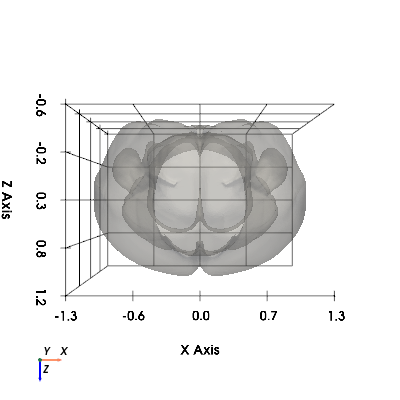

In [82]:
plotter = add_regions_mesh(Brain_Atlas.pv_mesh, notebook=True, window_size=[400, 400],
                         kwargs_dict={region_names[1]: {"color": "red"}, region_names[2]: {"color": "blue"}})
plotter.show_grid(font_size = 10 )
plotter.camera_position = 'zx'  # Set the camera position
plotter.camera.up = (0, 0, -1)  # Set the camera up direction
plotter.show(jupyter_backend='static')

Structure name: root
PyVista mesh atlas reset.


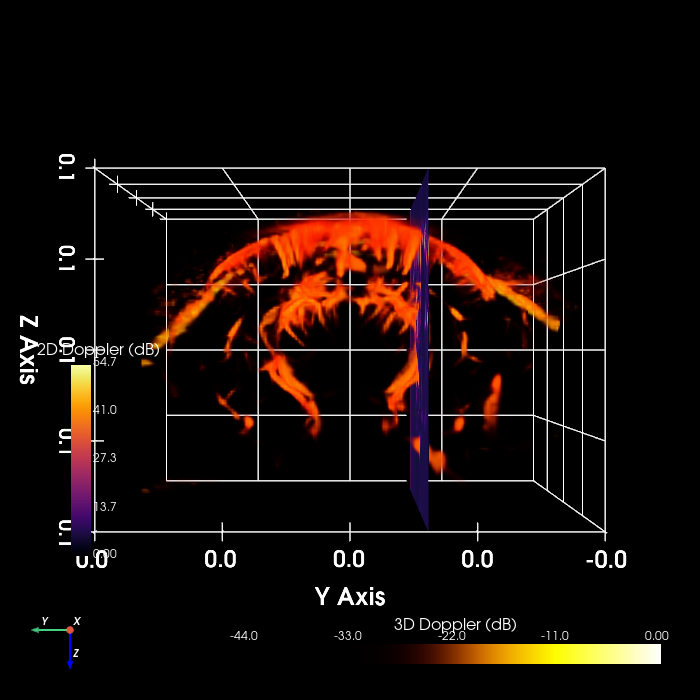

In [83]:
invertz = np.diag([1, 1, -1, 1])  # Invert z-axis for the transducer mesh
Brain_Atlas.reset_mesh()  # Reset the Brain Atlas mesh to the original mesh
Brain_Atlas.transform(T_matrix = invertz @ Doppler3D.BrainToLab  , inplace=True) 

plotter_lab = add_regions_mesh(Brain_Atlas.pv_mesh, plotter=plotter_lab)
plotter_lab.render()
plotter_lab.show(jupyter_backend='static')

# 4 Import transducer

During the experiment we have 3 spaces: Brain, Lab, Probe. Once we manage to have our atlas in lab coordinates, we could simplify them to Lab and probe. The lab reference frame will move averything around the probe reference frame. Then its pov is static. We must then take our transducer, set . The probe space will have its origin center in the probe, and if we have done a good aproximation of the length and height, then its x,y coordinates should not move

In [84]:
import pyfield.transducers as Transducers

print(Transducers.available_transducers())

domino = Transducers.Domino()

print(domino)


['LinearArrayTransducer', 'MatrixArrayTransducer', 'Domino', 'Zeus_Matrix']
LinearArrayTransducer initialized in 0.0000 seconds.
LinearArrayTransducer(n_elements=128, elem_width_mm=0.108, elem_height_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, FoverD=None)


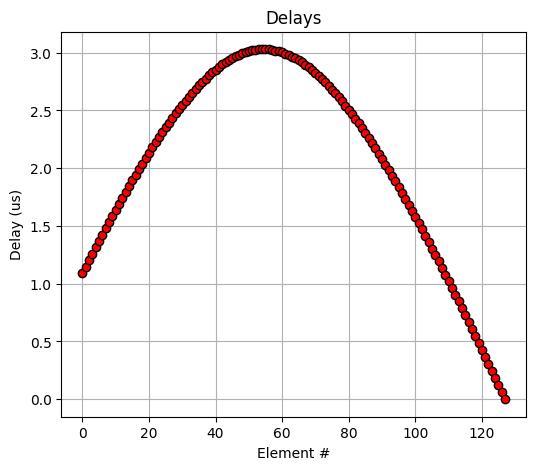

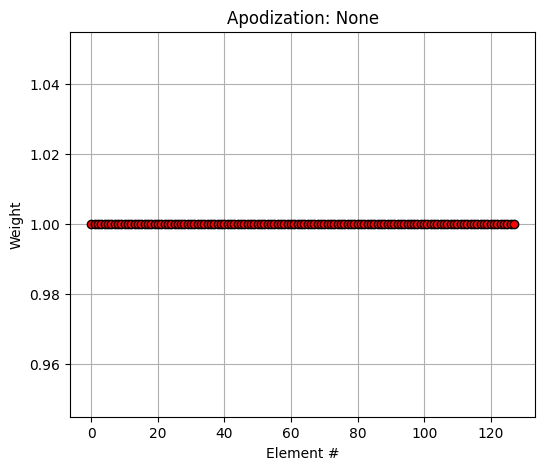

In [85]:
import numpy as np
from pyfield.psimulation import PyField

# Focalization spot
focus_mm =  np.array([-1, 0, 4.5])  # mm [x, y, z]
delays = domino.compute_delays(focus_mm = focus_mm, plot = True)
apodization = domino.compute_apodization(focus_mm = focus_mm, FoverD = 1, apodization_type='rect', plot = True)
domino.show(jupyter_backend='static')

In [86]:
TX_mesh = domino.get_mesh()

# 4. Take scan and atlas to probe space

In this case, the probe space will be located at the last plane acquisition thus on the 2D doppler image. Therefore, we must take the lab space back to the probe space of the 2D acquisition. However, we must first take the atlas to the lab space with the BPS information, and we must also fix the center of the transducer which is not the same.

In [87]:

def align_transducer_to_probe(TX_mesh, Doppler2D):
    """
    Align the transducer mesh to the probe mesh.
    Args:
        TX_mesh (pv.PolyData): The transducer mesh.
        Doppler2D (DopplerScan): The DopplerScan object containing the probe mesh.
    Returns:
        pv.PolyData: The aligned transducer mesh.
    """
    # Invert the
    invertz = np.diag([1, 1, -1, 1])  # Invert
    # Set the TX mesh origin
    x_min, x_max, y_min, y_max, z_min, z_max = TX_mesh.bounds
    TX_origin = np.array([x_min, y_min])
    Probe_origin = Doppler2D.voxelsToProbe[:2, 3]   # Set the origin to the mesh bounds

    set_TX_origin = np.eye(4)  # Create a 4x4 identity matrix for translation
    set_TX_origin[:2, 3] =  Probe_origin - TX_origin*1e-3  # Compute the translation vector to the transducer origin

    # rescale units from m to mm
    rescale_mToMm = np.diag([1000, 1000, 1000, 1])  # Scale factors for x, y, z, and homogeneous coordinate

    LabToProbe =  invertz @ rescale_mToMm @ set_TX_origin @ np.linalg.inv(Doppler2D.probeToLab) @ invertz  # Invert the probe to lab transformation matrix
    return LabToProbe

LabToProbe = align_transducer_to_probe(TX_mesh, Doppler2D)


In [88]:
Scan3D_probe = Doppler3D.transform(T_matrix= LabToProbe, inplace=False)  # Transform the scan mesh to the probe coordinate system
Scan2D_probe = Doppler2D.transform(T_matrix= LabToProbe, inplace=False)  # Transform the scan mesh to the probe coordinate system
BrainReg_probe = Brain_Atlas.transform(T_matrix= LabToProbe, inplace=False)  # Transform the atlas mesh to the probe coordinate system

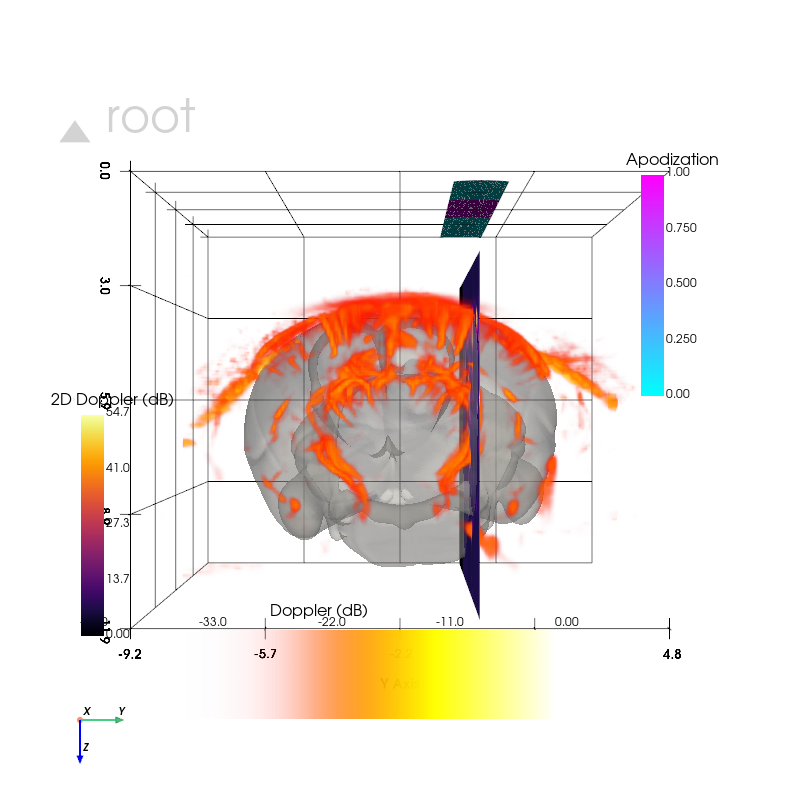

In [89]:
plotter3 = add_regions_mesh(BrainReg_probe,
                            notebook=True, window_size=[800, 800],
                            kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.2},	 
                                        region_names[1]: {"color": "permanentgreen", "opacity": 0.4}, 
                                        region_names[2]: {"color": "cadmiumlemon", "opacity": 0.6}})

plotter3 = add_3D_vol(Scan3D_probe, plotter = plotter3, cmap="hot", opacity="sigmoid_10")

plotter3 = add_transducer_mesh(TX_mesh,
                        plotter=plotter3, show_edges=False)

plotter3 = add_2D_image(Scan2D_probe, plotter=plotter3, cmap='inferno', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1)

plotter3.show_axes()
plotter3.show_grid(
    font_size = 10
)

plotter3.camera_position = 'zy'  # Set the camera position
plotter3.camera.up = (0, 0, -1)
plotter3.add_legend(loc = 'upper left')             # show legend
plotter3.set_background('white')  # Set background color to white
plotter3.show(jupyter_backend='static') # ,

# 5. Add Pressure Field

In [90]:
Domino_field = PyField(domino)
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.5+focus_mm[1], 0.5+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.0125,
    "dy" : 0.025,
    "dz" : 0.05,
}
print("Field info:", field_info_mm)
x, y, z,pressure_field = Domino_field(field_info_mm)

Field info: {'x_extent': [np.float64(-1.25), np.float64(-0.75)], 'y_extent': [np.float64(-0.5), np.float64(0.5)], 'z_extent': [np.float64(3.5), np.float64(5.5)], 'dx': 0.0125, 'dy': 0.025, 'dz': 0.05}
Computing SIR for 68921 points and 1280 patches...
Max distance: 9.96 mm, Min distance: 3.48 mm
Computed time grid from 2.17 us to 9.58 us, with 1482 samples in 0.02 seconds.
Transducer SIR computed in 0.23 seconds...
Pressure computed from SIR in 0.42 seconds...
Pressure field computed in 0.70 seconds...


Taking slice (-1.0,0.0,4.5) => x_ind, y_ind, z_ind = 21/41, 21/41, 21/41


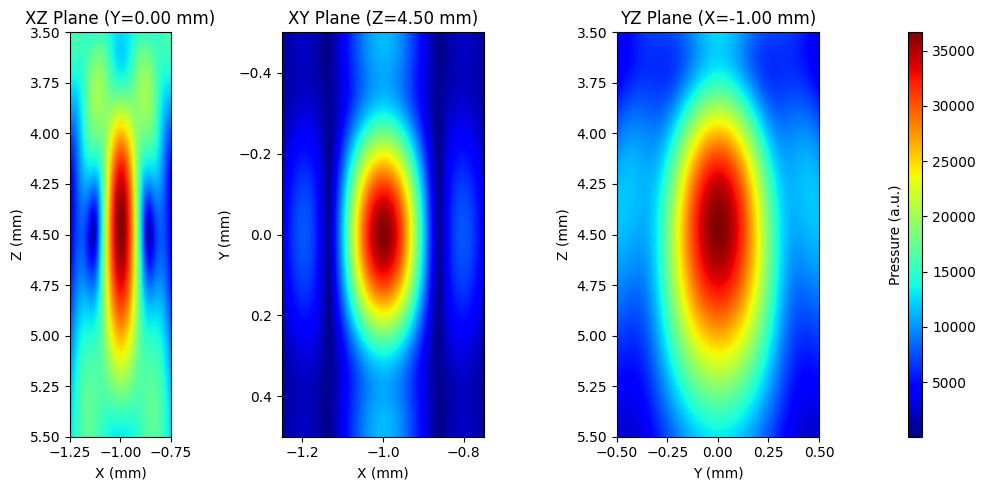

Pressure (u.a.)


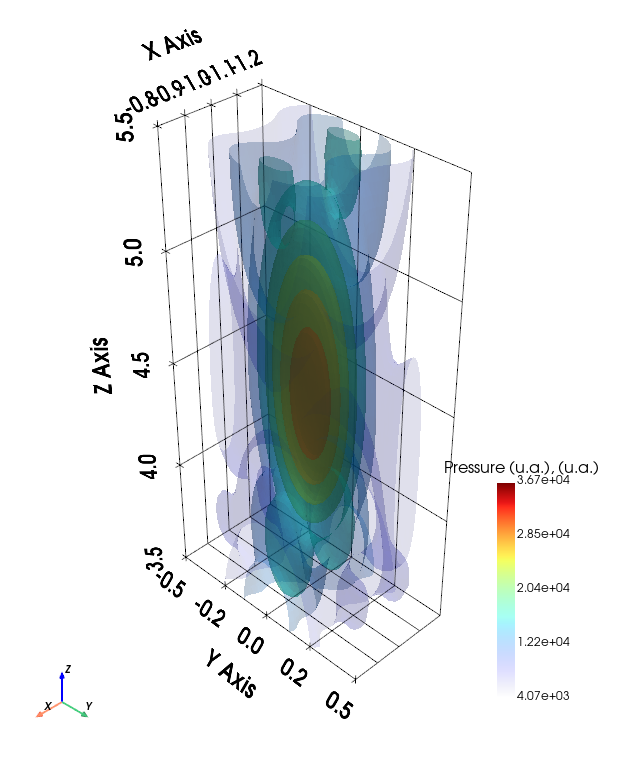

In [91]:
import pyfield
pyfield.plot_field_planes(x,y,z,pressure_field, figsize = (10, 5), interpolation="bilinear")

plotter=pyfield.plot_pressure_field(x, y, z,pressure_field, notebook = True, window_size = [620, 780])

plotter.show(jupyter_backend='static')  # Add this parameter

In [92]:
pressure_vol_mesh = pyfield.utilities.create_vol_mesh(x, y, z, pressure_field, scalars="pressure")

In [93]:
pressure_vol_mesh.point_data.keys()[0]

'pressure'

# 5. Plot brain and pressure field

pressure


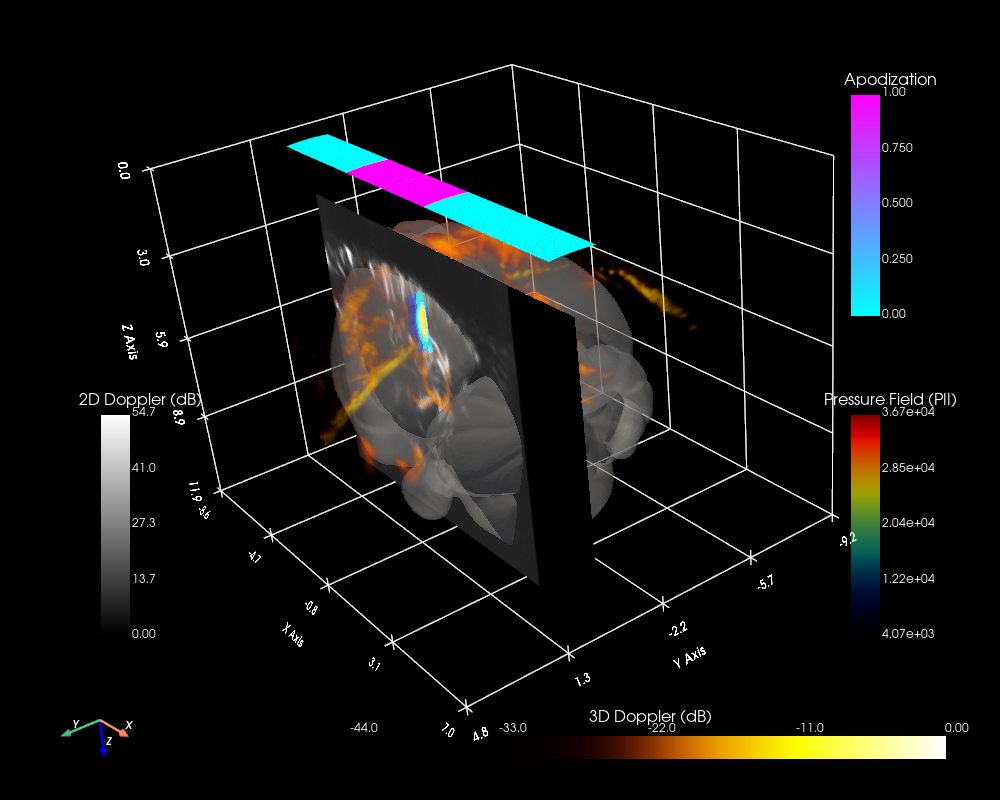

In [94]:
final_plotter = add_regions_mesh(BrainReg_probe,
                            notebook=True, window_size=[1000, 800],
                            kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.1},	 
                                        region_names[1]: {"color": "permanentgreen", "opacity": 0.2}, 
                                        region_names[2]: {"color": "cadmiumlemon", "opacity": 0.2}}, label = "Brain Atlas")

final_plotter = add_3D_vol(Scan3D_probe, plotter = final_plotter,
                                cmap="hot", opacity="sigmoid", opacity_unit_distance = 1,
                                scalar_bar_args={
                                    'title': '3D Doppler (dB)',
                                    "title_font_size": 16,
                                    "label_font_size": 12,
                                    'color' : 'white',
                                })

final_plotter = add_2D_image(Scan2D_probe, plotter=final_plotter, cmap='gray', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1,
                             scalar_bar_args={
                                    'title': '2D Doppler (dB)',
                                    "title_font_size": 16,
                                    "label_font_size": 12,
                                    'vertical': True,
                                    'position_x': 0.1,
                                    'position_y': 0.2,
                                    "height": 0.3,
                                    'color' : 'white',
                                })
                                 

final_plotter = add_transducer_mesh(TX_mesh,
                        plotter=final_plotter, show_edges=False, lighting=True, ambient=1,
                        scalar_bar_args={
                            'title': 'Apodization',
                            "title_font_size": 16,
                            "label_font_size": 12,
                            'vertical': True,
                            'position_x': 0.85,
                            'position_y': 0.6,
                            "height": 0.3,
                            'color' : 'white',
                        })

final_plotter = add_pressure_vol(pressure_vol_mesh,
                        plotter=final_plotter,
                        plot_focal_spot=False, lighting=True, ambient=1,
                        scalar_bar_args={
                            'title': 'Pressure Field (PII)',
                            "title_font_size": 16,
                            "label_font_size": 12,
                            'vertical': True,
                            'position_x': 0.85,
                            'position_y': 0.2,
                            "height": 0.3,
                            'color' : 'white',
                        })

# final_plotter.camera.up = (0, 0, -1)
# final_plotter.show_axes()
# final_plotter.show_grid(
#     font_size = 10
# )
final_plotter.set_background("black")
final_plotter.show_grid(color='white', font_size=10)  # Show grid with white color and font size 10
final_plotter.add_axes(color='white')
final_plotter.camera_position = 'zy'  # Set the camera position
final_plotter.camera.up = (0, 0, -1)  # Set the camera up direction
final_plotter.camera_position = [(35.3553561681614, 20.196200713709917, -14.240798942058916),
 (0.35035573008308757, -1.5421982237567053, 7.3213329246801795),
 (-0.3315987278689962, -0.33921900362926793, -0.8803253666982627)]
final_plotter.show(jupyter_backend='static')  # Show the plotter in Jupyter Notebook

In [95]:

final_plotter = add_regions_mesh(BrainReg_probe,
                            notebook=False, window_size=[800, 800],
                            kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.1},	 
                                        region_names[1]: {"color": "permanentgreen", "opacity": 0.2}, 
                                        region_names[2]: {"color": "cadmiumlemon", "opacity": 0.2}}, label = "Brain Atlas")

final_plotter = add_3D_vol(Scan3D_probe, plotter = final_plotter,
                                cmap="hot", opacity="sigmoid_10",
                                scalar_bar_args={
                                    'title': '3D Doppler (dB)',
                                    "title_font_size": 16,
                                    "label_font_size": 12,
                                    'color' : 'white',
                                })

final_plotter = add_2D_image(Scan2D_probe, plotter=final_plotter, cmap='inferno', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1,
                             scalar_bar_args={
                                    'title': '2D Doppler (dB)',
                                    "title_font_size": 16,
                                    "label_font_size": 12,
                                    'vertical': True,
                                    'position_x': 0.05,
                                    'position_y': 0.2,
                                    "height": 0.3,
                                    'color' : 'white',
                                })

final_plotter = add_transducer_mesh(TX_mesh,
                        plotter=final_plotter, show_edges=False, lighting=True, ambient=1,
                        scalar_bar_args={
                            'title': 'Apodization',
                            "title_font_size": 16,
                            "label_font_size": 12,
                            'vertical': True,
                            'position_x': 0.85,
                            'position_y': 0.6,
                            "height": 0.3,
                            'color' : 'white',
                        })

final_plotter = add_pressure_vol(pressure_vol_mesh,
                        plotter=final_plotter,
                        plot_focal_spot=False, lighting=True, ambient=1,
                        scalar_bar_args={
                            'title': 'PII',
                            "title_font_size": 16,
                            "label_font_size": 12,
                            'vertical': True,
                            'position_x': 0.85,
                            'position_y': 0.2,
                            "height": 0.3,
                            'color' : 'white',
                        })

final_plotter.set_background("black")
# final_plotter.show_grid(color='white', font_size=10)  # Show grid with white color and font size 10
final_plotter.add_axes(color='white')
final_plotter.camera_position = 'zy'  # Set the camera position
final_plotter.camera.up = (0, 0, -1)  # Set the camera up direction
final_plotter.show()  # Show the plotter in Jupyter Notebook

pressure


In [96]:
make_movie = False
video_filename = "doppler3Dand2D.mp4"

if make_movie:

    video_plotter = add_regions_mesh(BrainReg_probe,
                                notebook=True, window_size=[1400, 1000],
                                kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.1},	 
                                            region_names[1]: {"color": "permanentgreen", "opacity": 0.2}, 
                                            region_names[2]: {"color": "cadmiumlemon", "opacity": 0.2}}, label = "Brain Atlas")

    video_plotter = add_3D_vol(Scan3D_probe, plotter = video_plotter,
                                    cmap="hot", opacity="sigmoid", opacity_unit_distance = 1,
                                    scalar_bar_args={
                                        'title': '3D Doppler (dB)',
                                        "title_font_size": 16,
                                        "label_font_size": 12,
                                        'color' : 'white',
                                    })

    video_plotter = add_2D_image(Scan2D_probe, plotter=video_plotter, cmap='gray', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1,
                                scalar_bar_args={
                                        'title': '2D Doppler (dB)',
                                        "title_font_size": 16,
                                        "label_font_size": 12,
                                        'vertical': True,
                                        'position_x': 0.1,
                                        'position_y': 0.2,
                                        "height": 0.3,
                                        'color' : 'white',
                                    })
                                    

    video_plotter = add_transducer_mesh(TX_mesh,
                            plotter=video_plotter, show_edges=False, lighting=True, ambient=1,
                            scalar_bar_args={
                                'title': 'Apodization',
                                "title_font_size": 16,
                                "label_font_size": 12,
                                'vertical': True,
                                'position_x': 0.85,
                                'position_y': 0.6,
                                "height": 0.3,
                                'color' : 'white',
                            })

    video_plotter = add_pressure_vol(pressure_vol_mesh,
                            plotter=video_plotter,
                            plot_focal_spot=False, lighting=True, ambient=1,
                            scalar_bar_args={
                                'title': 'Pressure Field (PII)',
                                "title_font_size": 16,
                                "label_font_size": 12,
                                'vertical': True,
                                'position_x': 0.85,
                                'position_y': 0.2,
                                "height": 0.3,
                                'color' : 'white',
                            })

    video_plotter = add_3D_vol(Scan3D_probe, 
                                notebook=True, window_size=[1400, 1000],
                                    cmap="hot", opacity="sigmoid_10",
                                    scalar_bar_args={
                                        'title': '3D Doppler (dB)',
                                        "title_font_size": 16,
                                        "label_font_size": 12,
                                        'color' : 'white',
                                    })

    video_plotter = add_2D_image(Scan2D_probe, plotter=video_plotter, cmap='inferno', opacity=1.0, show_scalar_bar=True, lighting=True, ambient=1,
                                scalar_bar_args={
                                        'title': '2D Doppler (dB)',
                                        "title_font_size": 16,
                                        "label_font_size": 12,
                                        'vertical': True,
                                        'position_x': 0.1,
                                        'position_y': 0.2,
                                        "height": 0.3,
                                        'color' : 'white',
                                    })

    # final_plotter.camera.up = (0, 0, -1)
    # final_plotter.show_axes()
    # final_plotter.show_grid(
    #     font_size = 10
    # )
    video_plotter.set_background("black")
    video_plotter.show_grid(color='white', font_size=10)  # Show grid with white color and font size 10
    video_plotter.add_axes(color='white')
    video_plotter.camera_position = 'zy'  # Set the camera position
    video_plotter.camera.up = (0, 0, -1)  # Set the camera up direction


    # Render once before movie to apply camera and settings
    video_plotter.render()

    # Open movie file and define frame settings
    n_frames = 180
    video_plotter.open_movie(video_filename, framerate=20)

    # Rotation loop
    video_plotter.show(auto_close=False)

    delta_angle_deg = 360 / n_frames
    angle_deg = 0 
    for i in range(n_frames):
        angle_deg += 2
        video_plotter.camera.azimuth = angle_deg # Rotate camera
        video_plotter.render()
        video_plotter.write_frame()

    # Finalize and save
    video_plotter.close()
    print(f" Video saved to: {video_filename}")